In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
})


# WHY load from processed, not raw:
# annual_master.csv is our validated, merged foundation


annual = pd.read_csv('../data/processed/annual_master.csv')


print(f"Shape: {annual.shape}")
print(f"Columns: {annual.columns.tolist()}")
annual

Shape: (10, 8)
Columns: ['inflation_pct', 'gdp_usd', 'unemployment_pct', 'year', 'nikkei_avg_close', 'usd_jpy', 'boj_rate_pct', 'gdp_trillion']


,inflation_pct,gdp_usd,unemployment_pct,year,nikkei_avg_close,usd_jpy,boj_rate_pct,gdp_trillion
0,2.759227,4.985763e+12,3.589,2014,15460.432281,105.739800,0.204917,4.99
1,0.795280,4.534439e+12,3.385,2015,19203.767146,121.049084,0.169667,4.53
2,-0.127259,5.110357e+12,3.132,2016,16920.476295,108.656932,0.073667,5.11
3,0.484200,5.038232e+12,2.822,2017,20209.025446,112.098554,0.059333,5.04
4,0.989095,5.154294e+12,2.467,2018,22311.891872,110.397390,0.072333,5.15
5,0.468776,5.245755e+12,2.351,2019,21697.226173,109.018835,0.031083,5.25
6,-0.024996,5.189198e+12,2.809,2020,22703.032259,106.775440,-0.035417,5.19
7,-0.233353,5.225934e+12,2.808,2021,28836.538640,109.842892,-0.065500,5.23
8,2.497703,4.447976e+12,2.614,2022,27257.789895,131.458920,-0.029500,4.45
9,3.268134,4.384854e+12,2.600,2023,30716.555235,140.500120,0.003833,4.38


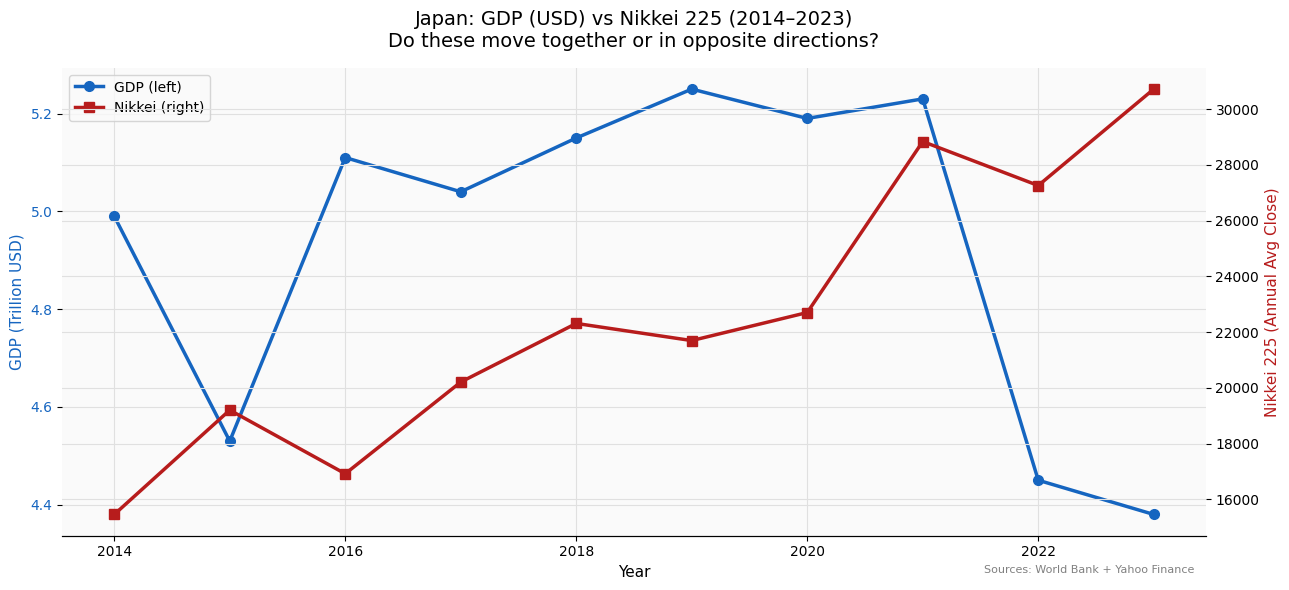

✓ Saved


In [2]:
# WHY dual-axis (twinx) here:
# GDP is in trillion, Nikkei is in tens of thousands - completely different scales, need separate y-axes


fig, ax1 = plt.subplots(figsize=(13, 6))

color_gdp = '#1565C0'
ax1.plot(annual['year'], annual['gdp_trillion'],
         color=color_gdp, linewidth=2.5,
         marker='o', markersize=7, label='GDP (left)')
ax1.set_ylabel("GDP (Trillion USD)", color=color_gdp, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_gdp)

ax2 = ax1.twinx()
color_nikkei = '#B71C1C'
ax2.plot(annual['year'], annual['nikkei_avg_close'],
         color=color_nikkei, linewidth=2.5,
         marker='s', markersize=7, label='Nikkei (right)')
ax2.set_ylabel("Nikkei 225 (Annual Avg Close)", 
               color=color_nikkei, fontsize=11)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           fontsize=10, loc='upper left')

ax1.set_title("Japan: GDP (USD) vs Nikkei 225 (2014–2023)\n"
              "Do these move together or in opposite directions?",
              fontsize=14, fontweight='500', pad=15)
ax1.set_xlabel("Year", fontsize=11)
ax1.text(0.99, -0.08, 'Sources: World Bank + Yahoo Finance',
         transform=ax1.transAxes, fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/gdp_vs_nikkei.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

In [3]:
# WHY calculate correlation here:
# The chart shows the SHAPE of the relationship visually.
# Correlation gives us the STRENGTH as one number

corr_gdp_nikkei = annual['gdp_trillion'].corr(annual['nikkei_avg_close'])

print(f"GDP vs Nikkei correlation: {corr_gdp_nikkei}")

if corr_gdp_nikkei < -0.3:
    print("→ Negative: GDP and Nikkei move in OPPOSITE directions")
elif corr_gdp_nikkei > 0.3:
    print("→ Positive: GDP and Nikkei move TOGETHER")
else:
    print("→ Weak/no clear relationship")

GDP vs Nikkei correlation: -0.35625409447346024
→ Negative: GDP and Nikkei move in OPPOSITE directions


## Key Finding 1 — GDP and Nikkei Move in Opposite Directions

[Write 3-4 sentences covering:
- The correlation number (-0.36) and what direction that means
- The 2022 divergence specifically (GDP crashed, Nikkei kept rising)
- WHY this happens — the yen's dual effect (hurts GDP/imports, 
  helps exporter profits/stocks)
- What this means for someone trying to judge "is Japan's economy 
  doing well" — GDP alone or Nikkei alone can be misleading]

## Key Finding 1 — GDP and Nikkei Move in Opposite Directions

- The correlation number (-0.36) confirms reasoning about Toyota's profits - GDP (in dollars) and Nikkei genuinely tend to move in opposite directions
over this decade, driven by the yen's effect on each measure differently.

-  In 2022, the yen get so much weak but Nikkei stock rises the conclution is GDP and the stock market are not the same thing, and can move in completely opposite directions during a currency crisis.

- how o 
